In [2]:
import polars as pl 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

In [3]:
df = pl.read_csv("../data/electricity_cost_dataset.csv")
print(f'Original dataset {df.shape}')
df.head()

Original dataset (10000, 9)


site area,structure type,water consumption,recycling rate,utilisation rate,air quality index,issue resolution time,resident count,electricity cost
i64,str,f64,i64,i64,i64,i64,i64,f64
1360,"""Mixed-use""",2519.0,69,52,188,1,72,1420.0
4272,"""Mixed-use""",2324.0,50,76,165,65,261,3298.0
3592,"""Mixed-use""",2701.0,20,94,198,39,117,3115.0
966,"""Residential""",1000.0,13,60,74,3,35,1575.0
4926,"""Residential""",5990.0,23,65,32,57,185,4301.0


In [4]:
def remove_outlier_iqr(df: pl.DataFrame, col:str) -> pl.DataFrame:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    before = df.shape[0]
    df = df.filter((pl.col(col) >= lower) & ((pl.col(col)) <= upper))
    after = df.shape[0]
    print(f'Deleted {before - after} strings (upper fence: {upper:.0f})')
    return df

df = remove_outlier_iqr(df, 'water consumption')
df = remove_outlier_iqr(df, 'resident count')

print(f'Dataset after deleting outliers: {df.shape}')

Deleted 43 strings (upper fence: 9359)
Deleted 285 strings (upper fence: 355)
Dataset after deleting outliers: (9672, 9)


In [5]:
df = df.with_columns(
    (pl.col('resident count') > 0).cast(pl.Int8).alias('has residents')
)

print('Has residents distribution')
print(df.group_by('has residents').agg(pl.len().alias('count')).sort('has residents'))

print('\nhas residents by building type')
print(
    df.group_by(['structure type', 'has residents'])
    .agg(pl.len().alias('count'))
    .sort(['structure type', 'has residents'])
)

Has residents distribution
shape: (2, 2)
┌───────────────┬───────┐
│ has residents ┆ count │
│ ---           ┆ ---   │
│ i8            ┆ u32   │
╞═══════════════╪═══════╡
│ 0             ┆ 3993  │
│ 1             ┆ 5679  │
└───────────────┴───────┘

has residents by building type
shape: (4, 3)
┌────────────────┬───────────────┬───────┐
│ structure type ┆ has residents ┆ count │
│ ---            ┆ ---           ┆ ---   │
│ str            ┆ i8            ┆ u32   │
╞════════════════╪═══════════════╪═══════╡
│ Commercial     ┆ 0             ┆ 2993  │
│ Industrial     ┆ 0             ┆ 1000  │
│ Mixed-use      ┆ 1             ┆ 1943  │
│ Residential    ┆ 1             ┆ 3736  │
└────────────────┴───────────────┴───────┘


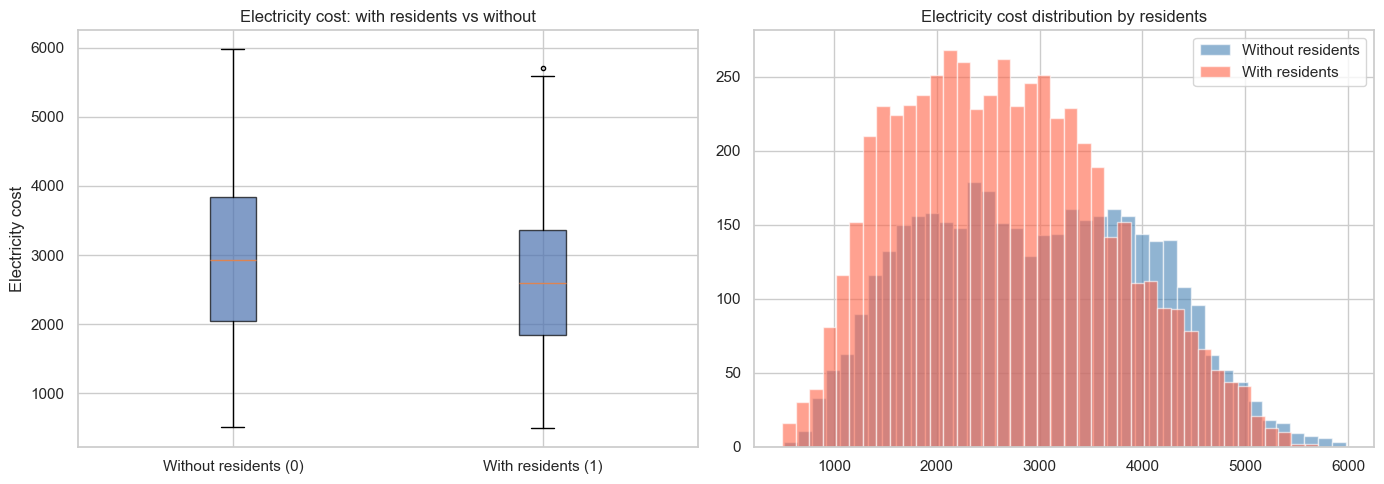

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

data_0 = df.filter(pl.col('has residents') == 0)['electricity cost'].to_numpy()
data_1 = df.filter(pl.col('has residents') == 1)['electricity cost'].to_numpy()

axes[0].boxplot([data_0, data_1], patch_artist=True,
                tick_labels=['Without residents (0)', 'With residents (1)'],
                boxprops=dict(alpha=0.7),
                flierprops=dict(marker='o', markersize=3))
axes[0].set_title('Electricity cost: with residents vs without')
axes[0].set_ylabel('Electricity cost')

axes[1].hist(data_0, bins=40, alpha=0.6, color='steelblue', label='Without residents')
axes[1].hist(data_1, bins=40, alpha=0.6, color='tomato', label='With residents')
axes[1].set_title('Electricity cost distribution by residents')
axes[1].legend()

plt.tight_layout()
plt.show();

In [7]:
structure_types = df['structure type'].unique().to_list()
print('Building types:', structure_types)

df = df.with_columns([
    (pl.col('structure type') == stype).cast(pl.Int8).alias(f'type_{stype.lower().replace("-", "_")}')
    for stype in structure_types
])

ohe_cols = [f'type_{s.lower().replace("-", "_")}' for s in structure_types]
print(f'New ohe features:')
print(df.select(ohe_cols).head(10))

Building types: ['Commercial', 'Residential', 'Mixed-use', 'Industrial']
New ohe features:
shape: (10, 4)
┌─────────────────┬──────────────────┬────────────────┬─────────────────┐
│ type_commercial ┆ type_residential ┆ type_mixed_use ┆ type_industrial │
│ ---             ┆ ---              ┆ ---            ┆ ---             │
│ i8              ┆ i8               ┆ i8             ┆ i8              │
╞═════════════════╪══════════════════╪════════════════╪═════════════════╡
│ 0               ┆ 0                ┆ 1              ┆ 0               │
│ 0               ┆ 0                ┆ 1              ┆ 0               │
│ 0               ┆ 0                ┆ 1              ┆ 0               │
│ 0               ┆ 1                ┆ 0              ┆ 0               │
│ 0               ┆ 1                ┆ 0              ┆ 0               │
│ 1               ┆ 0                ┆ 0              ┆ 0               │
│ 0               ┆ 1                ┆ 0              ┆ 0               │
│ 0   

In [8]:
print(df.schema)

Schema([('site area', Int64), ('structure type', String), ('water consumption', Float64), ('recycling rate', Int64), ('utilisation rate', Int64), ('air quality index', Int64), ('issue resolution time', Int64), ('resident count', Int64), ('electricity cost', Float64), ('has residents', Int8), ('type_commercial', Int8), ('type_residential', Int8), ('type_mixed_use', Int8), ('type_industrial', Int8)])


In [9]:
label_map = {'Residential': 0, 'Commercial': 1, 'Mixed-use': 2, 'Industrial': 3}

df = df.with_columns(
    pl.col('structure type').replace(label_map).cast(pl.Int8).alias('structure_type_enc')
)

print('Label Encoding:')
print(df.select(['structure type', 'structure_type_enc']).unique().sort('structure_type_enc'))

Label Encoding:
shape: (4, 2)
┌────────────────┬────────────────────┐
│ structure type ┆ structure_type_enc │
│ ---            ┆ ---                │
│ str            ┆ i8                 │
╞════════════════╪════════════════════╡
│ Residential    ┆ 0                  │
│ Commercial     ┆ 1                  │
│ Mixed-use      ┆ 2                  │
│ Industrial     ┆ 3                  │
└────────────────┴────────────────────┘


In [10]:
print('=== Final dataset features ===')
for col, dtype in df.schema.items():
    print(f'{col}: {dtype}')

print(f'\nShape: {df.shape}')

=== Final dataset features ===
site area: Int64
structure type: String
water consumption: Float64
recycling rate: Int64
utilisation rate: Int64
air quality index: Int64
issue resolution time: Int64
resident count: Int64
electricity cost: Float64
has residents: Int8
type_commercial: Int8
type_residential: Int8
type_mixed_use: Int8
type_industrial: Int8
structure_type_enc: Int8

Shape: (9672, 15)


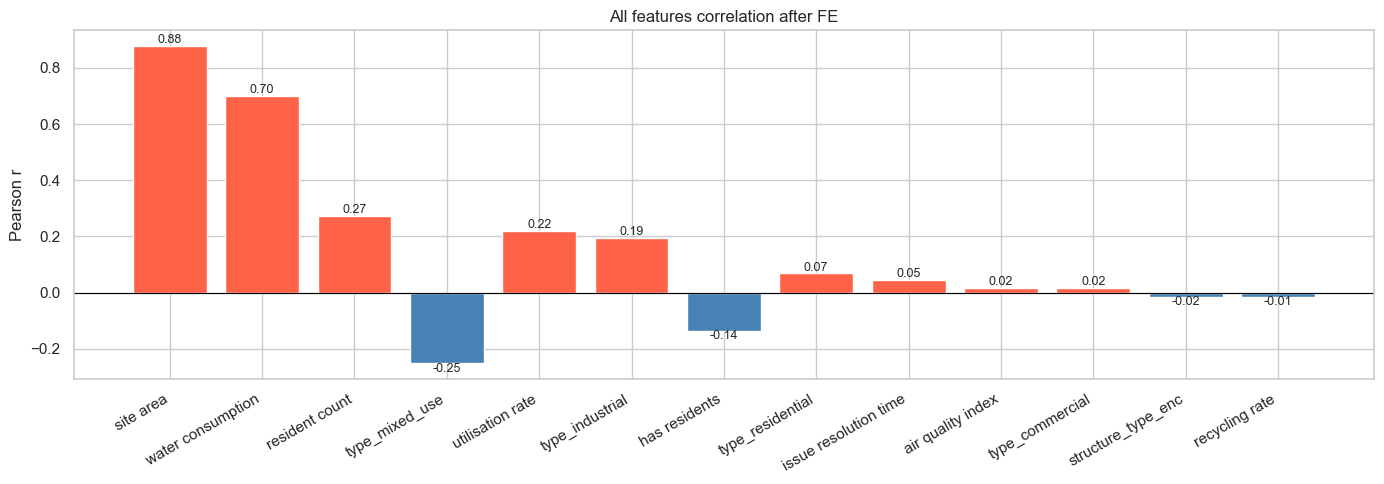

In [11]:
new_cols = ['has residents', 'structure_type_enc'] + ohe_cols
all_num_cols = [col for col, dtype in df.schema.items()
                if dtype in (pl.Float64, pl.Int64, pl.Int8)
                and col != 'electricity cost']

corr_vals = [
    (col, np.corrcoef(df[col].cast(pl.Float64).to_numpy(),
                      df['electricity cost'].to_numpy())[0,1])
    for col in all_num_cols
]

corr_vals.sort(key=lambda x: abs(x[1]), reverse=True)

cols_names = [c[0] for c in corr_vals]
corr_numbers = [c[1] for c in corr_vals]
bar_colors = ['tomato' if v > 0 else 'steelblue' for v in corr_numbers]

plt.figure(figsize=(14,5))
bars = plt.bar(cols_names, corr_numbers, color=bar_colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=0.8)
plt.title('All features correlation after FE')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Pearson r')
for bar, val in zip(bars, corr_numbers):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + (0.01 if val >= 0 else -0.03),
             f'{val:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
df.write_csv('../data/electricity_cost_fe.csv')
print('Saved')
print(df.shape)

X_linear = df.select([
    'site area', 'water consumption', 'recycling rate',
    'utilisation rate', 'air quality index', 'issue resolution time',
    'resident count', 'has residents'
] + ohe_cols)

X_boost = df.select([
    'site area', 'water consumption', 'recycling rate',
    'utilisation rate', 'air quality index', 'issue resolution time',
    'resident count', 'has residents',
    'structure_type_enc'  # 0-3
])

y = df.select('electricity cost')

X_linear.write_csv('../data/X_linear.csv')
X_boost.write_csv('../data/X_boost.csv')
y.write_csv('../data/y.csv')

print(f'X_linear: {X_linear.shape} — for linear models')
print(f'X_boost:  {X_boost.shape} — for boosted models')
print(f'y:        {y.shape}')

Saved
(9672, 15)
X_linear: (9672, 12) — for linear models
X_boost:  (9672, 9) — for boosted models
y:        (9672, 1)
